In [1]:
import xarray as xr
import rioxarray as riox
from rasterio.plot import show
import os
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
# LOCAL setup - CPU only with 32GB RAM
from dask.distributed import Client, LocalCluster
import os

num_jobs = os.cpu_count()//2 - 1  # Leave 1 core for system

cluster = LocalCluster(
    n_workers=num_jobs,
    threads_per_worker=2,
    memory_limit='28GB',  # Leave ~4GB for system
    processes=True  # Important for avoiding GIL issues
)

client = Client(cluster)
print(f'Local Dask cluster started:')
print(f'  Workers: {num_jobs}')
#print(f'  Memory per worker: 28GB / {num_jobs} = {28//num_jobs}GB')

display(client)

Local Dask cluster started:
  Workers: 23


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 23
Total threads: 46,Total memory: 599.77 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40555,Workers: 23
Dashboard: http://127.0.0.1:8787/status,Total threads: 46
Started: Just now,Total memory: 599.77 GiB
Comm: tcp://127.0.0.1:33527,Total threads: 2
Dashboard: http://127.0.0.1:38395/status,Memory: 26.08 GiB
Nanny: tcp://127.0.0.1:40323,


In [49]:
yr = 2026
inDIR = '/90daydata/cper_neon_aop/hls_nrt/gcloud/'
inDIR2 = '/90daydata/cper_neon_aop/hls_nrt/cper/hls_biomass'
inFILE = f'hls_cper_{yr}_gcloud.nc'
inFILE2 = f'cper_hls_bm_{yr}.nc'
cperPATH = '/project/cper_neon_aop/cper_hls_veg_models/extras/carm3/data/pastures/cper_pastures_2025_w_carm3_zones_w_excl.shp'

In [50]:
inDIR_raw = '/90daydata/cper_neon_aop/hls_nrt/cper/hls_biomass'
inFILE_raw = f'cper_hls_bm_{yr}_raw.nc'

In [51]:
date_comp = f'{yr}-06-06'

In [52]:
ds = riox.open_rasterio(os.path.join(inDIR, inFILE), masked=True)
ds2 = riox.open_rasterio(os.path.join(inDIR2, inFILE2), masked=True)
ds_raw = riox.open_rasterio(os.path.join(inDIR_raw, inFILE_raw), masked=True)

In [53]:
ds_raw

<xarray.DataArray 'Biomass' (time: 177, y: 325, x: 323)>
[18580575 values with dtype=float32]
Coordinates:
  * time         (time) object 2026-01-01 00:00:00 ... 2026-06-26 00:00:00
  * x            (x) float64 -1.167e+07 -1.167e+07 ... -1.165e+07 -1.165e+07
  * y            (y) float64 4.993e+06 4.993e+06 4.993e+06 ... 4.98e+06 4.98e+06
    spatial_ref  int64 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

In [54]:
if type(ds_raw) == xr.Dataset:
    ds_raw = ds_raw['Biomass']

In [55]:
bm_diff = ds['Biomass'].sel(date=date_comp) - ds_raw.sel(time=date_comp)

In [56]:
cper = gpd.read_file(cperPATH).to_crs(bm_diff.rio.crs)

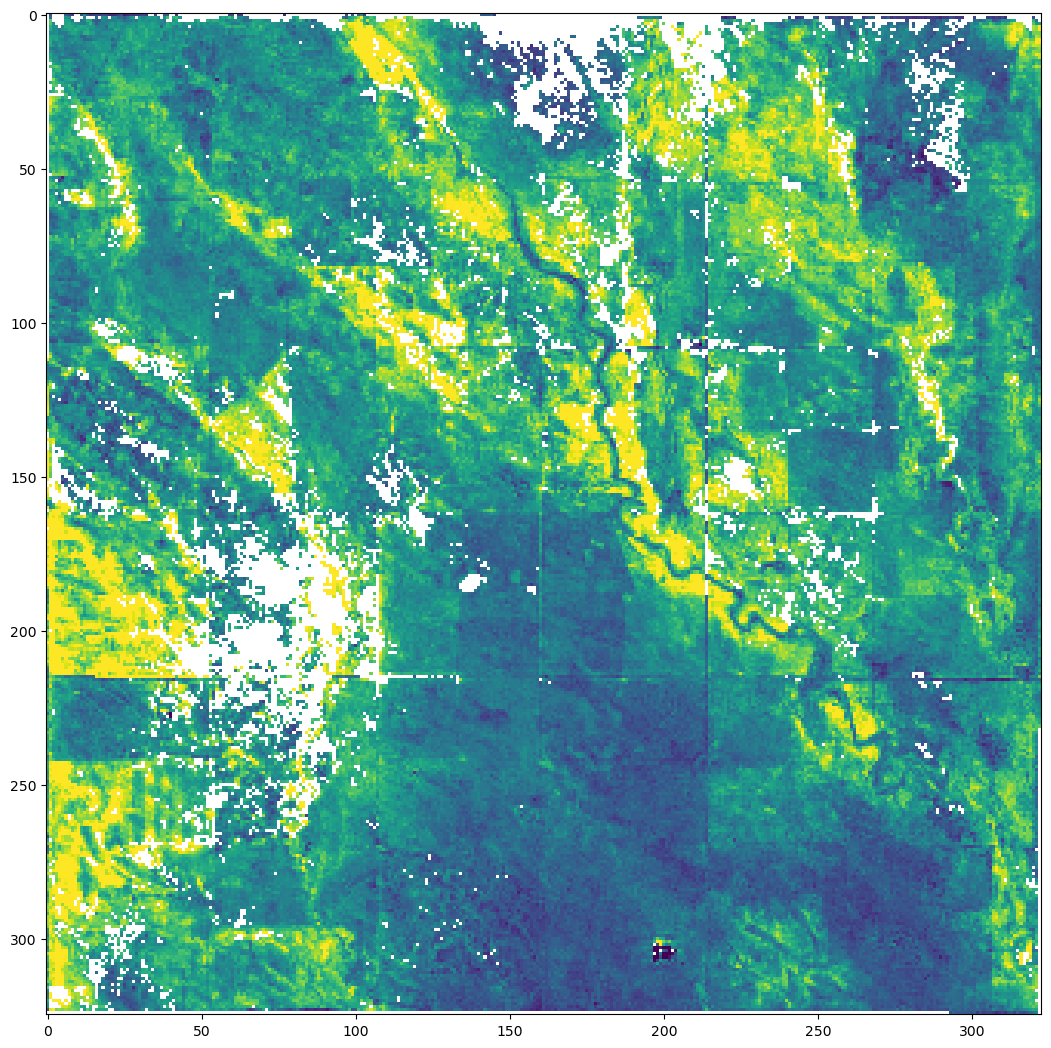

<AxesSubplot:>

In [57]:
fig, ax = plt.subplots(figsize=(13,13))
show(bm_diff.data, vmin=-300, vmax=0, cmap='viridis_r',
     #transform=bm_diff.rio.transform(),
     zorder=1)
#cper.plot(ax=ax, facecolor='none', zorder=10)

In [64]:
y=225
x=255
smoothed = ds['Biomass'].isel(y=y, x=x)
smoothed2 = ds2.isel(y=y, x=x)
raw = ds_raw.isel(y=y, x=x) * 0.892179

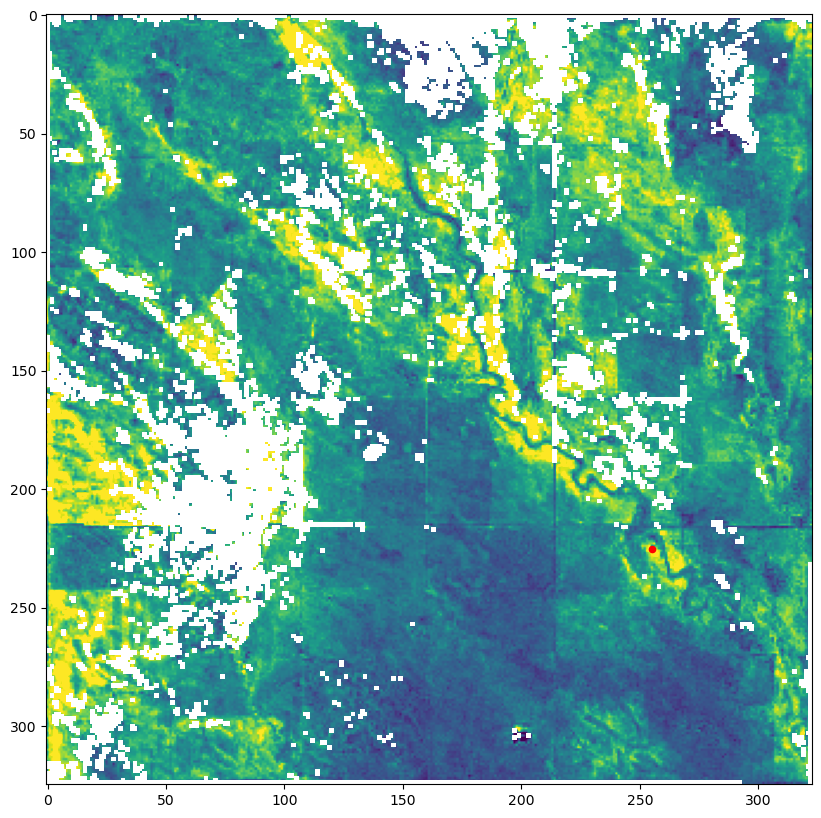

<AxesSubplot:>

In [65]:
fig, ax = plt.subplots(figsize=(10,10))
ax.scatter(x,y, s=20, c='red', zorder=100)
show(bm_diff.data, vmin=-300, vmax=0, cmap='viridis_r',
     #transform=bm_diff.rio.transform(),
     zorder=1)

In [66]:
import numpy as np

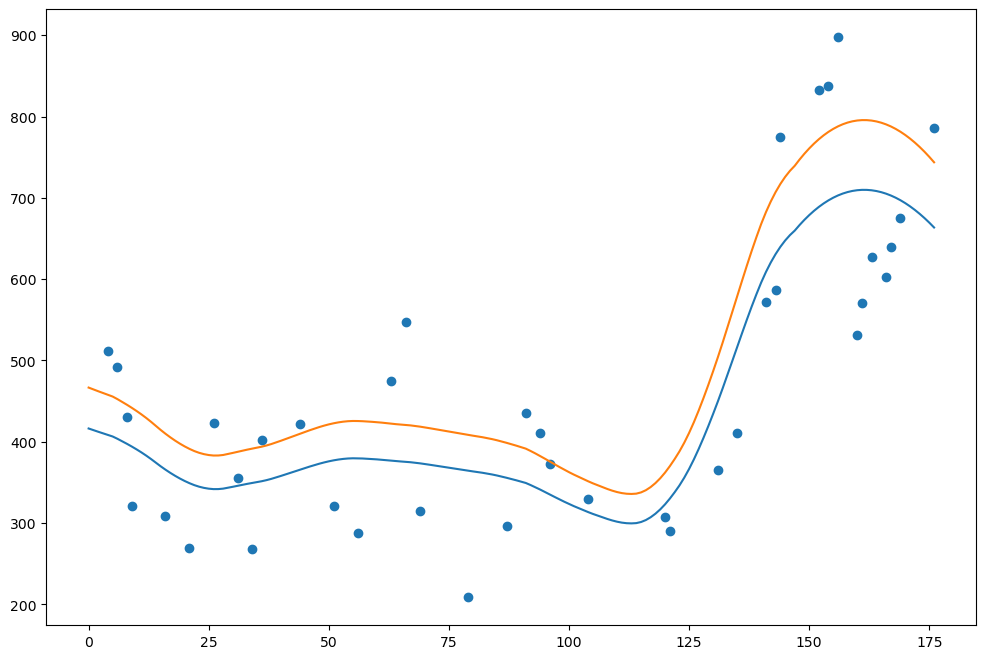

In [67]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(np.arange(len(ds_raw.time)), raw)
ax.plot(np.arange(len(ds_raw.time)), smoothed)
ax.plot(np.arange(len(ds_raw.time)), smoothed2)

In [68]:
from hlsstack.hls_funcs.smooth_new import smooth_xr_parallel

In [69]:
smooth_params = {
        'D': {
            'smooth_iters': 2,
            'smooth_window1_max': 21,
            'smooth_window2': 59,
            'smooth_limit': 91,
            'interpolate_na': 21},
        'W': {
            'smooth_iters': 1,
            'smooth_window1_max': 11,
            'smooth_window2': 7,
            'smooth_limit': 15,
            'interpolate_na': 3}}    

In [70]:
smooth_dict = smooth_params['D']

In [19]:
dat_out_da = smooth_xr_parallel(ds_raw.chunk({'time': -1, 'y': 20, 'x': 20}), 
                                smooth_dict)

Loading data into memory …
Smoothing 104975 pixels (53 tasks) on 48 logical cores (n_jobs=-1) …


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  53 | elapsed:   35.1s remaining: 14.9min
[Parallel(n_jobs=-1)]: Done  13 out of  53 | elapsed:   35.7s remaining:  1.8min
[Parallel(n_jobs=-1)]: Done  24 out of  53 | elapsed:   36.6s remaining:   44.2s
[Parallel(n_jobs=-1)]: Done  35 out of  53 | elapsed:   37.0s remaining:   19.0s
[Parallel(n_jobs=-1)]: Done  46 out of  53 | elapsed:   37.5s remaining:    5.7s
[Parallel(n_jobs=-1)]: Done  53 out of  53 | elapsed:   38.0s finished


In [71]:
from hlsstack.hls_funcs.smooth import double_savgol

In [72]:
smoothed_m = double_savgol(raw, **{'double': True, 
                                   'window1_max': smooth_dict['smooth_window1_max'],
                                   'window2': smooth_dict['smooth_window2'],
                                   'limit': smooth_dict['smooth_limit']})
                           #smooth_dict)

In [73]:
smoothed2 = dat_out_da.isel(y=y, x=x)

In [74]:
import pandas as pd
import datetime

In [75]:
dates = [datetime.datetime(yr, 1,1) + datetime.timedelta(days=int(x)) for x in np.arange(len(ds_raw.time))]

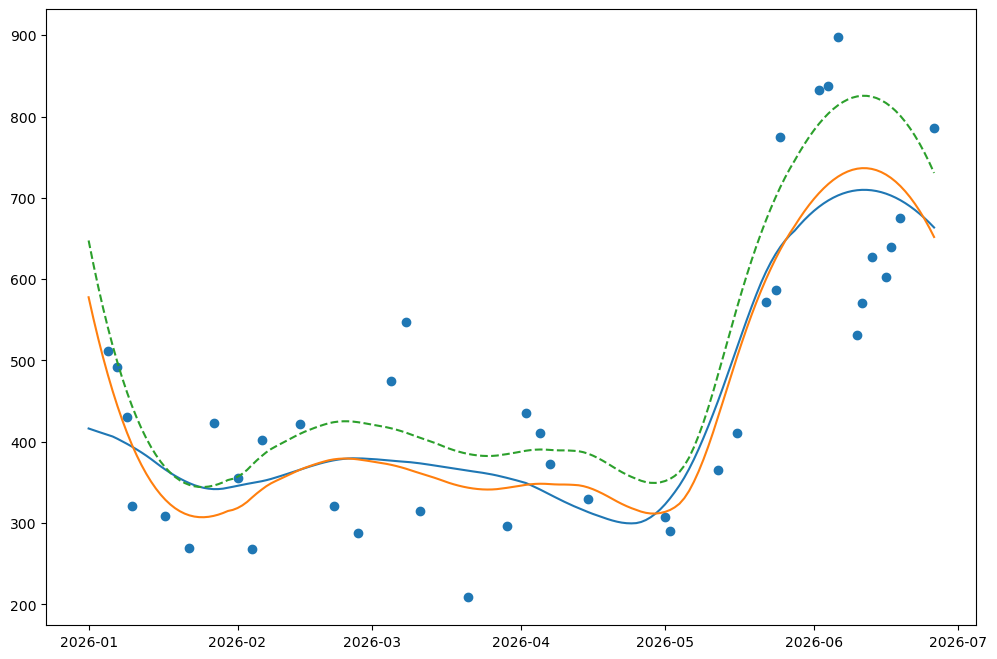

In [76]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(dates, raw)
ax.plot(dates, smoothed)
ax.plot(dates, smoothed_m)
ax.plot(dates, smoothed2, linestyle='dashed')

In [19]:
#dat_out_da = smooth_xr(ds_raw.chunk({'time': -1, 'y': 20, 'x': 20}), 
#                       dims=['time'], 
#                       kwargs={'double': True, 
#                               'window1_max': smooth_dict['smooth_window1_max'],
#                               'window2': smooth_dict['smooth_window2'],
#                               'limit': smooth_dict['smooth_limit']})

In [20]:
dat_smooth = dat_out_da.compute()

2026-06-23 14:46:57,801 - distributed.protocol.core - CRITICAL - Failed to deserialize
Traceback (most recent call last):
  File "/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/distributed/protocol/core.py", line 158, in loads
    return msgpack.loads(
  File "msgpack/_unpacker.pyx", line 194, in msgpack._cmsgpack.unpackb
  File "/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/distributed/protocol/core.py", line 138, in _decode_default
    return merge_and_deserialize(
  File "/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/distributed/protocol/serialize.py", line 497, in merge_and_deserialize
    return deserialize(header, merged_frames, deserializers=deserializers)
  File "/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/distributed/protocol/serialize.py", line 410, in deserialize
    deserialize(
  File "/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/dis

KilledWorker: Attempted to run task original-xarray-<this-array>-e4b215a4b810102a6997a44830f435cc on 3 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:44931. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

2026-06-23 14:47:07,014 - distributed.nanny - ERROR - Worker process died unexpectedly
2026-06-23 14:47:07,423 - distributed.nanny - ERROR - Worker process died unexpectedly


In [ ]:
ds_raw['time'][~ds_raw.isnull().all(dim=['y', 'x'])]